In [1]:
##modules
#%matplotlib widget
#%matplotlib inline
#
#%matplotlib qt
import mne
import numpy as np
import matplotlib
# Establecer un backend interactivo, como 'Qt5Agg', 'GTK3Agg', etc.
# Esto depende de los backends disponibles en tu sistema.

import matplotlib.pyplot as plt

matplotlib.use('TkAgg')  # Asegúrate de que este backend está instalado.

import pandas as pd 
import os
import sys

from mne.preprocessing import ICA, corrmap, create_ecg_epochs, create_eog_epochs

from os.path import join as pathjoin
from time import time

from pathlib import Path

from autoreject import AutoReject

# aplicar la acf EN epochs
from statsmodels.tsa.stattools import acf

import numpy as np

import pandas as pd


from joblib import Parallel, delayed

import pickle
sys.path.append(r"G:\apuntes_mne\code_MOUS\scripts_functions_created")

# Ahora importa la función
from print5 import print5


In [2]:

try:
    # Si se ejecuta como SCRIPT .py: usar __file__
    sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "..")))
except NameError:
    # Si se ejecuta como NOTEBOOK Jupyter: usar path relativo
    sys.path.append("..")  # sube un nivel desde la carpeta actual del notebook


# --- Configuración dinámica de rutas ---
from get_paths_SELF import get_paths_SELF

# Parámetros editables
disco = "g"
layer_script = "event"
subj = "s01b"


# Generar variables automáticamente
path_dict = get_paths_SELF(disco=disco, layer_script=layer_script, subj=subj)
globals().update(path_dict)

# Mostrar todos los paths generados
print("\n📁 Rutas generadas:")
for k, v in path_dict.items():
    print(f"{k:<20} → {v}")

    
    
    


✅ Carpeta creada: g:\PROYECTO_SELF\output_preproc\preproc_event\epochs_event
✅ Carpeta creada: g:\PROYECTO_SELF\output_preproc\preproc_event\ICA_event
✅ Carpeta creada: g:\PROYECTO_SELF\output_preproc\preproc_event\epochs_clean_event
✅ Carpeta creada: g:\PROYECTO_SELF\output_preproc\preproc_event\epochs_matlab_event
✅ Carpeta creada: g:\PROYECTO_SELF\output_preproc\preproc_event\evoked_event
✅ Carpeta creada: g:\PROYECTO_SELF\channels_structure
✅ Carpeta creada: g:\PROYECTO_SELF\output_source\source_event
✅ Carpeta creada: g:\PROYECTO_SELF\output_source\source_event\raw_hsp
✅ Carpeta creada: g:\PROYECTO_SELF\output_source\source_event\fwd
✅ Carpeta creada: g:\PROYECTO_SELF\output_source\source_event\inverse
✅ Carpeta creada: g:\PROYECTO_SELF\output_analysis\analysis_event\acw_event
✅ Carpeta creada: g:\PROYECTO_SELF\output_analysis\analysis_event\PLE_event
✅ Carpeta creada: g:\PROYECTO_SELF\output_analysis\analysis_event\ISC_event
✅ Carpeta creada: g:\PROYECTO_SELF\output_analysis\anal

# Tables and paths

### Paths
ACW_path
PLE_path

### Tables and metrics
#### Block

*ACW*
f"acw_results_subjects_all_{layer_script}.pickle"



f"autocorrelation_subjects_all_{layer_script}.pickle"

**variables** =  acw_50_elect_all_epoch_all //  'intercept_y_elect_all_epoch_all', 'slope_elect_all_epoch_all'


*PLE*
f"table_PLE_slope_intercept_subjects_all_{layer_script}.pickle"

f"table_PLE_subjects_all_{layer_script}.pickle"


#### dynamic

f"dynamic_autocorrelation_results_subjects_all_{layer_script}.pickle"

f"dynamic_autocorrelation_subjects_all_{layer_script}.pickle"

**variables** = acw_50_slope_elect_all_epoch_all   // acw_50_std_elect_all_epoch_all 

In [3]:
## Variables of script


##path=analysis_path
path = ACW_path
name_table = f"acw_results_subjects_all_{layer_script}.pickle"


table_df = pd.read_pickle(f"{path}\\{name_table}")


#METRIC NAMES
metric='acw_50_elect_all_epoch_all'


if '_elect_all_epoch_all' in metric:
    print("_elect_all_epoch_all in metric")
    metric_name = metric.replace('_elect_all_epoch_all', "")
else:
    metric_name = metric
    
##CONDITION NAMES
pickle_file = epochs_clean_path / f"dict_conditions.pkl"
# Cargar el pickle
with open(pickle_file, "rb") as f:
    dict_conditions = pickle.load(f)

#epochs
combinaciones = list(dict_conditions.keys())
print(f"combinaciones: {combinaciones}")

#TYPE OF DIFFERENCES
difference = "normal"  # "normal" or "inverse"

## this will be used in permutation differences
if difference == "normal":
    alternative = "greater" 
    # this is for cluster permutation test
    tail=1 
    threshold_direction =1
else:
    alternative="less"
    tail=-1
    threshold_direction =-1


p_cluster_value = 0.05 # p-value for cluster permutation test

number_decimals=6
# ##creacion dataframe acw_0

# acw_50_df = acw_all[["Subject", "Condition", "Epoch",
#                    "Elect", "acw_50_elect_all_epoch_all"]]
# acw_50_df.to_pickle(ACW_path / f"acw_50_df.pickle")

# del acw_50_df
# acw_0_df = acw_all[["Subject", "Condition", "Epoch",
#                    "Elect", "metric_elect_all_epoch_all"]]
# acw_0_df.to_pickle(ACW_path / f"acw_0_df.pickle")

# del acw_all
# del acw_0_df

_elect_all_epoch_all in metric
combinaciones: ['self_pos', 'self_neu', 'self_neg', 'friend_pos', 'friend_neu', 'friend_neg', 'unk_pos', 'unk_neu', 'unk_neg']


In [ ]:
table_df.head()

,Subject,Condition,Epoch,Elect,acw_50_elect_all_epoch_all,acw_0_elect_all_epoch_all
0,s01b,self_pos,0,Fp1,0.006,0.450
1,s01b,self_pos,0,Fpz,0.008,0.570
2,s01b,self_pos,0,Fp2,0.390,2.148
3,s01b,self_pos,0,AF7,0.330,1.848
4,s01b,self_pos,0,AF3,0.006,0.450


In [22]:

# channels = pd.read_csv(channels_structure_path / f"channels_mag.csv")
# channels_mag=channels[channels[f"canal_efectivo"].notna()][f"canal_efectivo"]

# channels_mag=channels_mag.tolist()
# print5(channels_mag)
# indice_channels_efectivos = channels[channels[f"canal_efectivo"].notna()]["indice"]
# indice_channels_efectivos=indice_channels_efectivos.tolist()
# # del channels

##valores de las columnas
condition = table_df["Condition"].unique()
print5("Condiciones en los datos:", condition)

subjects = table_df["Subject"].unique()
print5("Sujetos en los datos:", subjects)

elect_all=  table_df["Elect"].unique()
print5("sensores en los datos:", elect_all)

epochs_all=  table_df["Epoch"].unique()
print5("Epochs en los datos:", epochs_all)
## get info 

path_epochs= epochs_clean_path / f"{subj}_epochs_{combinaciones[0]}_{layer_script}-epo.fif"
epochs = mne.read_epochs(path_epochs)

info=epochs.info
del epochs


# añadimos identity and emotion a la tabla

table_df[['Identity', 'Emotion']] = table_df['Condition'].str.split('_', expand=True)
table_df = table_df[
    ['Subject', 'Condition','Identity', 'Emotion' , 'Epoch', 'Elect', 
     'acw_50_elect_all_epoch_all', 'acw_0_elect_all_epoch_all']
]

table_df.columns

Condiciones en los datos: ['self_pos' 'self_neu' 'self_neg' 'friend_pos' 'friend_neu' 'friend_neg'
 'unk_pos' 'unk_neu' 'unk_neg']
Sujetos en los datos: ['s01b' 's02b' 's03b']
sensores en los datos: ['Fp1' 'Fpz' 'Fp2' 'AF7' 'AF3' 'AF4' 'AF8' 'F7' 'F5' 'F3' 'F1' 'Fz' 'F2'
 'F4' 'F6' 'F8' 'FT7' 'FC5' 'FC3' 'FC1' 'FCz' 'FC2' 'FC4' 'FC6' 'FT8' 'T7'
 'C5' 'C3' 'C1' 'Cz' 'C2' 'C4' 'C6' 'T8' 'TP7' 'CP5' 'CP3' 'CP1' 'CPz'
 'CP2' 'CP4' 'CP6' 'TP8' 'P7' 'P5' 'P3' 'P1' 'Pz' 'P2' 'P4' 'P6' 'P8'
 'PO7' 'PO3' 'PO4' 'PO8' 'O1' 'Oz' 'O2']
Epochs en los datos: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]
Reading g:\PROYECTO_SELF\output_preproc\preproc_event\epochs_clean_event\s01b_epochs_self_pos_event-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...    9000.00 ms
        0 CTF compensation matrices available
Not setting metadata
32 matching events found
No baseline correction applied
0 projection items activated


Index(['Subject', 'Condition', 'Identity', 'Emotion', 'Epoch', 'Elect',
       'acw_50_elect_all_epoch_all', 'acw_0_elect_all_epoch_all'],
      dtype='object')

## Selection of values

In [7]:
### testing with pandas, nomenclature includes ONLY what is preserved, not what has been averaged

# this is for comparing between conditions, as it has dimension=number of subjects
metric_cond_subj_epoch_mean_elect_mean= table_df.groupby(["Subject", "Condition"])[metric].mean().reset_index()

#this is for plotting results (plot_topomap) as it has dimension=number of electrodes
metric_cond_subj_mean_epoch_mean_elect=table_df.groupby(["Condition", "Elect"])[metric].mean().reset_index()

#this is for cluster permutation test, as it has dimension=number of subjects and electrodes 
metric_cond_subj_epoch_mean_elect=table_df.groupby(["Subject", "Condition", "Elect"])[metric].mean().reset_index()

# Plots 

## Plot topomat of activation

In [10]:
# 
for exp_condition in combinaciones:
    # Filtrar el DataFrame por la condición actual
    filtered_df = metric_cond_subj_mean_epoch_mean_elect.query("Condition == @exp_condition")

    # Extraer los valores de la métrica y los nombres de los electrodos
    values = filtered_df[metric].values.flatten()
    electrodes = filtered_df["Elect"].values

    # Asegurarse de que los valores y los electrodos tienen la misma longitud
    if len(values) != len(electrodes):
        raise ValueError("Los valores y los electrodos deben tener la misma longitud.")

    # Crea figura + eje manual
    fig, ax = plt.subplots(figsize=(6, 6))

    # Imprimir para depuración
    # print5(f"Valores para {exp_condition}: {values}")
    # print5(f"Electrodos para {exp_condition}: {electrodes}")
    
    
    # Dibujar topomap DENTRO de ese eje
    im, _ = mne.viz.plot_topomap(
        data=values,
        pos=info,
        axes=ax,           # ← esto asegura que se dibuja donde tú quieres
        cmap='RdBu_r',
        vlim=(-np.max(np.abs(values)), np.max(np.abs(values))),
        mask=None,
        contours=0,
        show=False         # ← evita que se muestre automáticamente
    )

    # Título
    fig.suptitle(f"{metric_name} values in {exp_condition}", fontsize=20)

    # Añadir barra de color (leyenda)
    cbar = fig.colorbar(im, ax=ax, shrink=0.6)
    cbar.set_label(f"{metric_name} value")

    # Mostrar figura
    plt.show()


### linear plots

In [11]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt


#metric_cond_subj_epoch_mean_elect shouldnt be used but plot gets uninformative, when all subjects, use metric_cond_subj_epoch_mean_elect_mean


# Crear diccionario con los arrays planos de cada condición
dict_conditions_flat = {}
for cond in combinaciones:
    condition_flat = metric_cond_subj_epoch_mean_elect.query("Condition == @cond")[metric].values.flatten()
    dict_conditions_flat[cond] = condition_flat

# Crear figura
plt.figure(figsize=(10, 5))

# Colores para condiciones (puedes ajustar o automatizar más)
colors = ['blue', 'red', 'green', 'orange', 'purple']
counts_dict = {}
kde_dict = {}

for idx, cond in enumerate(combinaciones):
    data = dict_conditions_flat[cond]

    # Histograma
    counts, bins, _ = plt.hist(
        data,
        bins=150,
        alpha=0.4,
        label=f'{cond}',
        color=colors[idx % len(colors)]
    )
    counts_dict[cond] = counts

    # KDE
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min(), data.max(), 300)
    scaled_kde = kde(x_vals) * len(data) * np.diff(bins)[0]
    kde_dict[cond] = scaled_kde

    # Graficar KDE
    plt.plot(
        x_vals,
        scaled_kde,
        linestyle='--',
        color=colors[idx % len(colors)],
        label=f'{cond} (KDE)'
    )

# Ejes y leyenda
plt.xlabel(f"{metric_name}(s)")
plt.ylabel("Número de valores")
plt.title(f"Histograms  + KDE for conditions in {metric_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# General differences between woorden and zinnen conditions

In [26]:
import pingouin as pg
for i in ["acw_50_elect_all_epoch_all", "acw_0_elect_all_epoch_all"]:
    anova = pg.rm_anova(
        data=table_df,
        dv=i,  # o la métrica que estés usando
        within=['Identity', 'Emotion'],
        subject='Subject',
        detailed=True
    )

    print(anova)


               Source        SS  ddof1  ddof2        MS         F     p-unc  \
0            Identity  0.001654      2      4  0.000827  3.085832  0.154645   
1             Emotion  0.001134      2      4  0.000567  0.717513  0.541647   
2  Identity * Emotion  0.001828      4      8  0.000457  0.729839  0.596240   

   p-GG-corr       ng2       eps  
0   0.209291  0.001203  0.572788  
1   0.533753  0.000825  0.909679  
2   0.505009  0.001329  0.192660  
               Source        SS  ddof1  ddof2        MS         F     p-unc  \
0            Identity  0.018814      2      4  0.009407  2.035745  0.245591   
1             Emotion  0.007534      2      4  0.003767  0.483280  0.648647   
2  Identity * Emotion  0.015188      4      8  0.003797  1.464326  0.298895   

   p-GG-corr       ng2       eps  
0   0.287760  0.003586  0.520539  
1   0.627470  0.001439  0.855693  
2   0.356767  0.002896  0.234400  


c:\Users\UCM\anaconda3\envs\env_meg\Lib\site-packages\pingouin\distribution.py:515: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(
c:\Users\UCM\anaconda3\envs\env_meg\Lib\site-packages\pingouin\distribution.py:515: UserWarning: Epsilon values might be innaccurate in two-way repeated measures design where each  factor has more than 2 levels. Please  double-check your results.
  warnings.warn(


In [ ]:
# #take values for electrodes, dimension=number of subjects
# dict_conditions_flat = {}
# for cond in combinaciones:
#     condition_flat = metric_cond_subj_epoch_mean_elect_mean.query("Condition == @cond")[metric].values.flatten()
#     dict_conditions_flat[cond] = condition_flat

# ##dependent condition
# def paired_statistic(diff, _):
#     return np.mean(diff)


# print5(f"Differences in {metric_name} between conditions")
# for cond in combinaciones:
#     if cond==condition_1_name:
#         print(f"x is {cond} and {condition_1_name}")
#         x= dict_conditions_flat[cond]
#     if cond==condition_2_name:
#         print(f"y is {cond} and {condition_2_name}")
#         y=dict_conditions_flat[cond]

# diff = x - y
# # Permutation test
# res = permutation_test(
#     (diff, np.zeros_like(diff)),
#     statistic=paired_statistic,
#     vectorized=False,
#     n_resamples=10000,
#     alternative=alternative, 
#     random_state=42
# )

# print5(f"Statistic value: {res.statistic:.{number_decimals}f}")
# print5(f"p-value: {res.pvalue}")


# # d of Cohen


# mean_diff = np.mean(diff)
# std_diff = np.std(diff, ddof=1)  # ddof=1 para usar la desviación muestral

# cohens_d = mean_diff / std_diff

# print5(f"Cohen's d (paired): {cohens_d:.{number_decimals}f}")


Differences in slope between conditions
x is zinnen and zinnen
y is woorden and woorden
Statistic value: -0.00725
p-value: 0.00660
Cohen's d (paired): -0.59959


# Cluster analysis

## Datos a comparar

ahora tengo por cada condición: subject x epoch x channel

#### procedimiento

- promediar a nivel de epoca para tener subject x channel (luego probaré a hacerlo de otra manera sin promediar)

- ejecutar permutation cluster based analysis usando mi acw_zinnen vs mi acw_woorden  que va a estar como subject x channel

    - el cluster solo puede ser espacial, porque mis epocas son discontinuas, creo que esto es adjacency 

#### Resultados

T_obs: La estadística observada en cada punto.
clusters: Los clústeres formados por puntos significativos adyacentes.
cluster_p_values: Los valores p de cada clúster (ya corregidos por comparaciones múltiples).
H0: La distribución nula obtenida por permutaciones.



Supongo que clusters y sus valores de significacioón
Luego no se como se compara entre condiciones, pero de momemento vamos así

## Cluster in differences

In [ ]:
##get adjacency value
adjacency_reduced =  pd.read_pickle(channels_structure_path /f"adjacency_reduced.pkl")
###print5(f"shape adjacency_reduced: {adjacency_reduced.shape}")

In [ ]:
##note that condition_1 and condition_2 are 2D arrays with shape (n_subjects, n_channels)

#here im using various things
##.query("Condition ==@cond") = [metric_cond_subj_epoch_mean_elect["Condition"]=cond]
#pivot index="Subject",columns="Elect", values=metric) gives toy a a table with indexes and columns
#to_numpy converts the table to a numpy array, removin names of indexes and columns

for cond in combinaciones:
    if cond==condition_1_name:
        print(f"x is {cond} and {condition_1_name}")
        x= metric_cond_subj_epoch_mean_elect.query("Condition ==@cond").pivot(index="Subject",columns="Elect", values=metric).to_numpy()   
    if cond==condition_2_name:
        print(f"y is {cond} and {condition_2_name}")
        y=metric_cond_subj_epoch_mean_elect.query("Condition ==@cond").pivot(index="Subject",columns="Elect", values=metric).to_numpy()   

print(f"x.shape is {x.shape}")
print(f"y.shape is {y.shape}")
diff= x-y 
print5(f"diff.shape is {diff.shape}")




# as I´m going to apply differences to same subjects, i need a DEPENDENT t test kind of thing, 
# so instead of mne.stats.permutation_cluster_test I´m going to use mne.stats.permutation_cluster_1samp_test

# mne.stats.permutation_cluster_1samp_test(X, threshold=None, n_permutations=1024, tail=0, stat_fun=None, adjacency=None, n_jobs=None, seed=None, max_step=1, exclude=None, 
#                                          step_down_p=0, t_power=1, out_type='indices', check_disjoint=False, buffer_size=1000, verbose=None)

# as im going to put zinnen before woorden i need tail=1

#instead of puting X with bot condigions, i will put the difference between them diff=zinnen-woorden
# i modify the value of the tail to be -1, because i want to see if the values of zinnen are lower than the values of woorden
from scipy.stats import t

t_thresh = (threshold_direction ) * t.ppf(1 - p_cluster_value, df=len(subjects) - 1)


t_obs_diff, clusters_diff, clusters_pv_diff, H0=mne.stats.permutation_cluster_1samp_test(diff, threshold=t_thresh, n_permutations=1024, tail=tail, 
                                                                          stat_fun=None, adjacency=adjacency_reduced, n_jobs=15, seed=None, max_step=1, exclude=None,
                                                                          step_down_p=0, t_power=1, out_type='indices', check_disjoint=False, buffer_size=1000, verbose=None)


# Obtenemos los clusters como listas de índices
# Filtrar clusters con p < 0.05
#zip links clusters y p-values
significant_clusters_diff = [
    cluster for cluster, p in zip(clusters_diff, clusters_pv_diff) if p < 0.05
]

print5(f"{len(significant_clusters_diff)} significative clusters found.")
print5(f"{metric_name}Clusters significative: {significant_clusters_diff}")

x is zinnen and zinnen
y is woorden and woorden
x.shape is (18, 273)
y.shape is (18, 273)
diff.shape is (18, 273)
stat_fun(H1): min=-4.667770657680899 max=0.6795120813074376
Running initial clustering …
Found 3 clusters


100%|██████████| Permuting : 1023/1023 [00:03<00:00,  276.73it/s]

1 significative clusters found.
slopeClusters significative: [(array([ 16,  57,  61,  62,  77,  80,  81,  85,  86,  91,  92,  93, 130,
       132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144,
       145, 146, 147, 148, 149, 150, 151, 152, 153, 165, 166, 167, 171,
       172, 173, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187,
       188, 189, 190, 192, 193, 194, 196, 206, 207, 208, 209, 210, 211,
       212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224,
       225, 226, 227, 228, 229, 230, 231, 232, 233, 235, 236, 237, 238,
       239, 240, 243, 244, 245, 246, 251, 252, 253, 256, 257, 258, 259,
       262, 263, 264, 265, 272]),)]


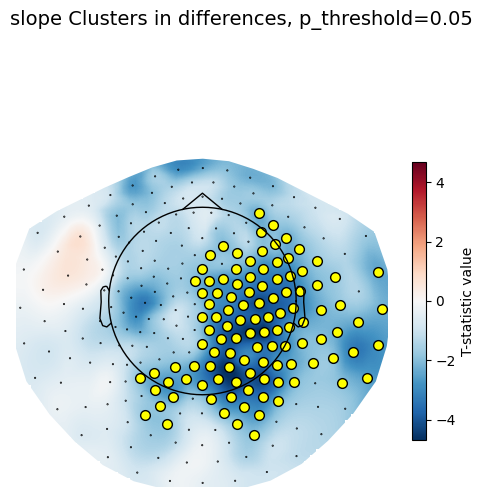

In [108]:
###PLOTSS

mask_diff = np.zeros(t_obs_diff.shape, dtype=bool)

##significant_clusters_diff is a list of tuples of arrays
# cluster[0] is the electrodes of the  cluster
for cluster in significant_clusters_diff:
    mask_diff[cluster[0]] = True 



##in data i use the value of t_obs_diff
#pos takes the information from evoked.info object
#mask takes the mask_diff object
#in t stat i don´t change it becausse the p value will be calculated with permutations, so no problem when using a parametric test,
# even if the distribution is non parametric 

# Crear figura y eje
fig, ax = plt.subplots(figsize=(6, 6))

# Dibujar el topomap
im, _ = mne.viz.plot_topomap(
    data=t_obs_diff,
    pos=info,
    mask=mask_diff,
    axes=ax,
    cmap='RdBu_r',
    vlim=(-np.max(np.abs(t_obs_diff)), np.max(np.abs(t_obs_diff))),
    mask_params=dict(marker='o', markerfacecolor='yellow', markersize=7),
    contours=0,
    show=False
)

# Añadir título
fig.suptitle(f"{metric_name} Clusters in differences, p_threshold={p_cluster_value}", fontsize=14)

# Añadir barra de color
cbar = fig.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label("T-statistic value")

# Mostrar el gráfico
plt.show()